In [3]:
# Install required libraries
!pip install torch torchvision torchaudio
!pip install librosa soundfile
!pip install scikit-learn pandas numpy matplotlib seaborn
!pip install opencv-python
!pip install kaggle tqdm

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Setup your Kaggle credentials
import os
os.makedirs('/root/.kaggle', exist_ok=True)

# Write your Kaggle credentials
kaggle_config = '''{"username": "stalin143", "key": "bf24d31431c3472ea855c8041021b7b4"}'''
with open('/root/.kaggle/kaggle.json', 'w') as f:
    f.write(kaggle_config)

!chmod 600 /root/.kaggle/kaggle.json

# Create project directories
!mkdir -p /content/drive/MyDrive/WomenSafetyAI
!mkdir -p /content/datasets

print("✅ Environment setup complete with your Kaggle credentials!")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Environment setup complete with your Kaggle credentials!


In [4]:
import pandas as pd
import numpy as np
import librosa
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Download high-quality datasets for women's safety
print("🔄 Downloading real audio datasets...")

datasets_to_download = [
    # Emotional speech datasets - perfect for danger detection
    ("uwrfkaggler/ravdess-emotional-speech-audio", "ravdess"),
    ("ejlok1/toronto-emotional-speech-set-tess", "tess"),
    ("dmitrybabko/speech-emotion-recognition-en", "speech_emotion"),

    # Speech commands - for emergency keywords
    ("tensorflow/speech-commands", "speech_commands"),

    # Additional emergency-related datasets
    ("anuvagoyal/speech-emotion-recognition-for-emergency-calls", "emergency_calls"),
]

for dataset_id, folder_name in datasets_to_download:
    try:
        print(f"Downloading {dataset_id}...")
        !kaggle datasets download -d {dataset_id} -p /content/datasets/{folder_name}/
        !cd /content/datasets/{folder_name}/ && unzip -q *.zip
        print(f"✅ Downloaded: {folder_name}")
    except Exception as e:
        print(f"⚠️ Could not download {dataset_id}: {e}")

print("✅ All datasets downloaded!")

# Check what we actually got
for folder in ['ravdess', 'tess', 'speech_emotion', 'speech_commands', 'emergency_calls']:
    path = f'/content/datasets/{folder}/'
    if os.path.exists(path):
        file_count = sum([len(files) for r, d, files in os.walk(path)])
        print(f"📁 {folder}: {file_count} files")


🔄 Downloading real audio datasets...
Dataset URL: https://www.kaggle.com/datasets/uwrfkaggler/ravdess-emotional-speech-audio
License(s): CC-BY-NC-SA-4.0
 88% 378M/429M [00:06<00:01, 49.3MB/s]
100% 429M/429M [00:06<00:00, 65.4MB/s]
✅ Downloaded: ravdess
Dataset URL: https://www.kaggle.com/datasets/ejlok1/toronto-emotional-speech-set-tess
License(s): Attribution-NonCommercial-NoDerivatives 4.0 International (CC BY-NC-ND 4.0)
 93% 398M/428M [00:00<00:00, 360MB/s]
100% 428M/428M [00:01<00:00, 417MB/s]
✅ Downloaded: tess
Dataset URL: https://www.kaggle.com/datasets/dmitrybabko/speech-emotion-recognition-en
License(s): copyright-authors
 99% 979M/987M [00:07<00:00, 324MB/s]
100% 987M/987M [00:07<00:00, 139MB/s]
✅ Downloaded: speech_emotion
403 Client Error: Forbidden for url: https://www.kaggle.com/api/v1/datasets/metadata/tensorflow/speech-commands
/bin/bash: line 1: cd: /content/datasets/speech_commands/: No such file or directory
✅ Downloaded: speech_commands
Dataset URL: https://www.kagg

In [5]:
class WomenSafetyDataProcessor:
    """Advanced processor for women's safety detection using real audio data"""

    def __init__(self, sample_rate=22050, duration=4.0):
        self.sample_rate = sample_rate
        self.duration = duration
        self.max_len = int(sample_rate * duration)

        # Map emotions to safety levels based on women's safety research
        self.emotion_to_safety = {
            # Safe levels (0)
            'neutral': 0, 'calm': 0, 'happy': 0, 'pleasant_surprised': 0,
            # Alert levels (1)
            'sad': 1, 'surprised': 1, 'disgust': 1,
            # Emergency levels (2)
            'angry': 2, 'fear': 2, 'fearful': 2,
            # Critical levels (3)
            'scream': 3, 'panic': 3
        }

        # Emergency keywords in multiple Indian languages + English
        self.emergency_keywords = {
            # English
            'help', 'emergency', 'danger', 'attack', 'scared', 'save', 'police', 'stop', 'no',
            # Hindi
            'bachao', 'madad', 'madad karo', 'police bulao', 'khatre mein hun',
            # Tamil
            'uthavi', 'kaappathunga', 'aalpaattu', 'police azhaiyunga',
            # Bengali
            'sahayya', 'baanchao', 'bipod', 'police daak',
            # Other Indian languages
            'vaachva', 'baachavo', 'kaapaadinchandi', 'rakshikkuka'
        }

        # Feature dimensions
        self.audio_dim = 50  # Comprehensive audio features
        self.context_dim = 15  # Context features (time, location, etc.)
        self.total_dim = self.audio_dim + self.context_dim

    def extract_comprehensive_audio_features(self, audio_path):
        """Extract state-of-the-art audio features for danger detection"""
        try:
            # Load audio
            y, sr = librosa.load(audio_path, sr=self.sample_rate, duration=self.duration)

            if len(y) == 0:
                return np.zeros(self.audio_dim)

            # Normalize and ensure consistent length
            y = librosa.util.normalize(y)
            if len(y) > self.max_len:
                y = y[:self.max_len]
            else:
                y = np.pad(y, (0, max(0, self.max_len - len(y))))

            features = []

            # 1. MFCC features (13 coefficients + deltas)
            mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
            mfcc_delta = librosa.feature.delta(mfcc)
            features.extend(np.mean(mfcc.T, axis=0))      # 13 features
            features.extend(np.std(mfcc.T, axis=0))       # 13 features
            features.extend(np.mean(mfcc_delta.T, axis=0)) # 13 features

            # 2. Prosodic features (crucial for emotion/stress detection)
            # Pitch analysis
            f0 = librosa.yin(y, fmin=librosa.note_to_hz('C2'), fmax=librosa.note_to_hz('C7'))
            pitch_values = f0[f0 > 0]
            if len(pitch_values) > 0:
                features.extend([
                    np.mean(pitch_values),    # Mean pitch
                    np.std(pitch_values),     # Pitch variation
                    np.max(pitch_values),     # Max pitch
                    np.min(pitch_values)      # Min pitch
                ])
            else:
                features.extend([0, 0, 0, 0])

            # 3. Energy and rhythm features
            rms_energy = librosa.feature.rms(y=y)[0]
            features.extend([
                np.mean(rms_energy),      # Mean energy
                np.std(rms_energy),       # Energy variation
                np.max(rms_energy)        # Peak energy
            ])

            # 4. Spectral features
            spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
            spectral_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)[0]
            zcr = librosa.feature.zero_crossing_rate(y)[0]

            features.extend([
                np.mean(spectral_centroid),  # Brightness
                np.mean(spectral_rolloff),   # Spectral rolloff
                np.mean(zcr),                # Speaking rate indicator
                np.std(zcr)                  # Speech rhythm variation
            ])

            # 5. Harmonic and percussive components
            y_harmonic, y_percussive = librosa.effects.hpss(y)
            features.extend([
                np.mean(librosa.feature.rms(y=y_harmonic)[0]),    # Harmonic energy
                np.mean(librosa.feature.rms(y=y_percussive)[0])   # Percussive energy
            ])

            return np.array(features[:self.audio_dim])

        except Exception as e:
            print(f"Error processing {audio_path}: {e}")
            return np.zeros(self.audio_dim)

    def create_context_features(self, safety_level):
        """Create contextual features based on safety level"""
        # Simulate realistic context based on danger level
        features = []

        # Time-based features
        hour = np.random.randint(0, 24)
        is_night = 1 if (hour < 6 or hour > 22) else 0
        is_peak_danger_time = 1 if (22 <= hour <= 2) else 0

        # Location safety features (simulated)
        area_safety_score = max(0.1, 0.9 - safety_level * 0.2)  # Lower score = more dangerous
        distance_to_safe_zone = safety_level * 0.5 + np.random.uniform(0, 0.3)

        # Movement features (simulated accelerometer)
        movement_intensity = safety_level * 0.3 + np.random.uniform(0, 0.2)

        # Physiological features (simulated)
        stress_indicators = safety_level * 0.4 + np.random.uniform(0, 0.1)

        context_features = [
            hour / 24.0,           # Normalized hour
            is_night,              # Night indicator
            is_peak_danger_time,   # Peak danger time
            area_safety_score,     # Area safety score
            distance_to_safe_zone, # Distance to safety
            movement_intensity,    # Movement patterns
            stress_indicators,     # Stress level
            np.random.uniform(0, 1),  # Additional context features
            np.random.uniform(0, 1),
            np.random.uniform(0, 1),
            np.random.uniform(0, 1),
            np.random.uniform(0, 1),
            np.random.uniform(0, 1),
            np.random.uniform(0, 1),
            np.random.uniform(0, 1)
        ]

        return np.array(context_features[:self.context_dim])

    def load_ravdess_dataset(self):
        """Load RAVDESS emotional speech dataset"""
        audio_files, labels = [], []

        base_path = '/content/datasets/ravdess/'
        if os.path.exists(base_path):
            for root, dirs, files in os.walk(base_path):
                for file in files:
                    if file.endswith('.wav') and len(file.split('-')) >= 3:
                        try:
                            file_path = os.path.join(root, file)
                            # RAVDESS format: 03-01-06-01-02-01-12.wav
                            # Position 2 is emotion: 01=neutral, 02=calm, 03=happy, 04=sad,
                            # 05=angry, 06=fearful, 07=disgust, 08=surprised
                            emotion_code = int(file.split('-')[2])
                            emotion_mapping = {
                                1: 'neutral', 2: 'calm', 3: 'happy', 4: 'sad',
                                5: 'angry', 6: 'fearful', 7: 'disgust', 8: 'surprised'
                            }

                            if emotion_code in emotion_mapping:
                                emotion = emotion_mapping[emotion_code]
                                safety_level = self.emotion_to_safety.get(emotion, 0)
                                audio_files.append(file_path)
                                labels.append(safety_level)
                        except:
                            continue

        print(f"✅ RAVDESS: {len(audio_files)} samples loaded")
        return audio_files, labels

    def load_tess_dataset(self):
        """Load TESS dataset"""
        audio_files, labels = [], []

        base_path = '/content/datasets/tess/'
        if os.path.exists(base_path):
            for root, dirs, files in os.walk(base_path):
                for file in files:
                    if file.endswith('.wav'):
                        file_path = os.path.join(root, file)
                        filename_lower = file.lower()

                        # Extract emotion from filename
                        detected_emotion = None
                        for emotion in self.emotion_to_safety.keys():
                            if emotion in filename_lower:
                                detected_emotion = emotion
                                break

                        if detected_emotion:
                            safety_level = self.emotion_to_safety[detected_emotion]
                            audio_files.append(file_path)
                            labels.append(safety_level)

        print(f"✅ TESS: {len(audio_files)} samples loaded")
        return audio_files, labels

    def load_speech_commands_dataset(self):
        """Load speech commands focusing on emergency words"""
        audio_files, labels = [], []

        base_path = '/content/datasets/speech_commands/'
        emergency_command_mapping = {
            'help': 2, 'stop': 2, 'no': 1,      # Emergency/Alert commands
            'yes': 0, 'up': 0, 'down': 0, 'on': 0, 'off': 0  # Normal commands
        }

        if os.path.exists(base_path):
            for command, safety_level in emergency_command_mapping.items():
                command_path = os.path.join(base_path, command)
                if os.path.exists(command_path):
                    files = [f for f in os.listdir(command_path) if f.endswith('.wav')][:200]  # Limit samples
                    for file in files:
                        file_path = os.path.join(command_path, file)
                        audio_files.append(file_path)
                        labels.append(safety_level)

        print(f"✅ Speech Commands: {len(audio_files)} samples loaded")
        return audio_files, labels

    def create_comprehensive_dataset(self, min_samples=4000):
        """Create comprehensive dataset from all sources"""
        print("🔄 Creating comprehensive women's safety dataset...")

        all_files, all_labels = [], []

        # Load real datasets
        ravdess_files, ravdess_labels = self.load_ravdess_dataset()
        tess_files, tess_labels = self.load_tess_dataset()
        commands_files, commands_labels = self.load_speech_commands_dataset()

        # Combine all real data
        all_files.extend(ravdess_files + tess_files + commands_files)
        all_labels.extend(ravdess_labels + tess_labels + commands_labels)

        print(f"📊 Real audio samples: {len(all_files)}")
        print(f"📊 Label distribution: {np.bincount(all_labels)}")

        # Add synthetic data if needed
        if len(all_files) < min_samples:
            synthetic_needed = min_samples - len(all_files)
            print(f"🔄 Adding {synthetic_needed} synthetic samples...")

            for i in range(synthetic_needed):
                # Create realistic label distribution
                if i < synthetic_needed * 0.5:    # 50% safe
                    label = 0
                elif i < synthetic_needed * 0.75:  # 25% alert
                    label = 1
                elif i < synthetic_needed * 0.92:  # 17% emergency
                    label = 2
                else:                              # 8% critical
                    label = 3

                all_files.append(f"synthetic_{i}.wav")
                all_labels.append(label)

        return all_files, all_labels

# Initialize processor and create dataset
print("🚀 Initializing advanced data processor...")
processor = WomenSafetyDataProcessor()
audio_files, labels = processor.create_comprehensive_dataset()

print(f"✅ Complete dataset ready:")
print(f"📊 Total samples: {len(audio_files)}")
print(f"📊 Final distribution: {dict(zip(['Safe', 'Alert', 'Emergency', 'Critical'], np.bincount(labels)))}")


🚀 Initializing advanced data processor...
🔄 Creating comprehensive women's safety dataset...
✅ RAVDESS: 2880 samples loaded
✅ TESS: 4804 samples loaded
✅ Speech Commands: 0 samples loaded
📊 Real audio samples: 7684
📊 Label distribution: [2580 2744 2360]
✅ Complete dataset ready:
📊 Total samples: 7684
📊 Final distribution: {'Safe': np.int64(2580), 'Alert': np.int64(2744), 'Emergency': np.int64(2360)}


In [6]:
class AdvancedWomenSafetyNet(nn.Module):
    """State-of-the-art neural network for women's safety detection"""

    def __init__(self, input_dim=65, num_classes=4):
        super(AdvancedWomenSafetyNet, self).__init__()

        # Input processing
        self.input_norm = nn.LayerNorm(input_dim)
        self.input_dropout = nn.Dropout(0.1)

        # Multi-scale feature extraction
        self.feature_blocks = nn.ModuleList([
            # Block 1: Local patterns
            nn.Sequential(
                nn.Linear(input_dim, 256),
                nn.ReLU(),
                nn.BatchNorm1d(256),
                nn.Dropout(0.3)
            ),
            # Block 2: Global patterns
            nn.Sequential(
                nn.Linear(input_dim, 256),
                nn.ReLU(),
                nn.BatchNorm1d(256),
                nn.Dropout(0.3)
            )
        ])

        # Feature fusion
        self.feature_fusion = nn.Sequential(
            nn.Linear(512, 512),  # Combined features
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.4)
        )

        # Self-attention mechanism
        self.attention = nn.MultiheadAttention(
            embed_dim=512, num_heads=8, dropout=0.1, batch_first=True
        )

        # Advanced classification head
        self.classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.2),

            nn.Linear(128, num_classes)
        )

        # Emergency binary classifier (auxiliary task)
        self.emergency_head = nn.Sequential(
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

        # Confidence estimation head
        self.confidence_head = nn.Sequential(
            nn.Linear(512, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        # Input normalization
        x = self.input_norm(x)
        x = self.input_dropout(x)

        # Multi-scale feature extraction
        block_outputs = []
        for block in self.feature_blocks:
            block_outputs.append(block(x))

        # Fuse features
        fused_features = torch.cat(block_outputs, dim=1)
        fused_features = self.feature_fusion(fused_features)

        # Self-attention (reshape for attention)
        attn_input = fused_features.unsqueeze(1)  # Add sequence dimension
        attn_output, _ = self.attention(attn_input, attn_input, attn_input)
        attended_features = attn_output.squeeze(1)  # Remove sequence dimension

        # Multi-task outputs
        safety_logits = self.classifier(attended_features)
        emergency_prob = self.emergency_head(attended_features)
        confidence_score = self.confidence_head(attended_features)

        return safety_logits, emergency_prob, confidence_score

# Initialize model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🔥 Using device: {device}")

model = AdvancedWomenSafetyNet(
    input_dim=processor.total_dim,
    num_classes=4
)
model = model.to(device)

# Model summary
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"✅ Advanced model initialized:")
print(f"📊 Total parameters: {total_params:,}")
print(f"📊 Trainable parameters: {trainable_params:,}")
print(f"📊 Input dimension: {processor.total_dim}")


🔥 Using device: cpu
✅ Advanced model initialized:
📊 Total parameters: 1,613,448
📊 Trainable parameters: 1,613,448
📊 Input dimension: 65


In [7]:
class AdvancedWomenSafetyDataset(Dataset):
    """High-performance dataset class"""

    def __init__(self, audio_files, labels, processor):
        self.audio_files = audio_files
        self.labels = labels
        self.processor = processor

        print("🔄 Extracting advanced features from all samples...")
        self.features = []

        from tqdm import tqdm

        for i, (audio_file, label) in enumerate(tqdm(zip(audio_files, labels), total=len(audio_files))):
            # Extract audio features
            if audio_file.startswith('synthetic_'):
                # Create synthetic features with realistic patterns
                audio_features = np.random.randn(processor.audio_dim) * (0.3 + label * 0.4)
                # Add label-specific patterns
                if label >= 2:  # Emergency/Critical
                    audio_features[40:45] += np.random.uniform(0.5, 1.0, 5)  # Higher energy
                    audio_features[1:4] += np.random.uniform(0.3, 0.8, 3)   # Pitch variation
            else:
                # Extract real audio features
                audio_features = processor.extract_comprehensive_audio_features(audio_file)

            # Create context features
            context_features = processor.create_context_features(label)

            # Combine features
            combined_features = np.concatenate([audio_features, context_features])
            self.features.append(combined_features)

        self.features = np.array(self.features, dtype=np.float32)
        self.labels = np.array(labels, dtype=np.int64)

        # Create auxiliary labels
        self.emergency_labels = (self.labels >= 2).astype(np.float32)  # Binary emergency detection

        print(f"✅ Feature extraction completed:")
        print(f"📊 Feature shape: {self.features.shape}")
        print(f"📊 Feature range: [{np.min(self.features):.3f}, {np.max(self.features):.3f}]")
        print(f"📊 Emergency samples: {np.sum(self.emergency_labels)} / {len(self.emergency_labels)}")

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return (
            torch.FloatTensor(self.features[idx]),
            torch.LongTensor([self.labels[idx]]).squeeze(),
            torch.FloatTensor([self.emergency_labels[idx]]).squeeze()
        )

# Create dataset
print("🚀 Creating advanced dataset...")
dataset = AdvancedWomenSafetyDataset(audio_files, labels, processor)

# Advanced train/test split with stratification
X_indices = np.arange(len(dataset))
train_idx, test_idx, _, _ = train_test_split(
    X_indices, labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

# Further split training into train/validation
train_idx, val_idx, _, _ = train_test_split(
    train_idx, [labels[i] for i in train_idx],
    test_size=0.2,
    random_state=42,
    stratify=[labels[i] for i in train_idx]
)

# Create data loaders
train_dataset = torch.utils.data.Subset(dataset, train_idx)
val_dataset = torch.utils.data.Subset(dataset, val_idx)
test_dataset = torch.utils.data.Subset(dataset, test_idx)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"✅ Advanced data loaders created:")
print(f"📊 Train: {len(train_dataset)} samples ({len(train_loader)} batches)")
print(f"📊 Validation: {len(val_dataset)} samples ({len(val_loader)} batches)")
print(f"📊 Test: {len(test_dataset)} samples ({len(test_loader)} batches)")


🚀 Creating advanced dataset...
🔄 Extracting advanced features from all samples...


100%|██████████| 7684/7684 [37:13<00:00,  3.44it/s]

✅ Feature extraction completed:
📊 Feature shape: (7684, 65)
📊 Feature range: [-469.187, 6862.931]
📊 Emergency samples: 2360.0 / 7684
✅ Advanced data loaders created:
📊 Train: 4917 samples (154 batches)
📊 Validation: 1230 samples (39 batches)
📊 Test: 1537 samples (49 batches)


In [10]:
# Advanced multi-task loss function
class AdvancedMultiTaskLoss(nn.Module):
    def __init__(self, class_weights, alpha=0.7, beta=0.2, gamma=0.1):
        super().__init__()
        self.classification_loss = nn.CrossEntropyLoss(weight=class_weights)
        self.emergency_loss = nn.BCELoss()
        self.confidence_loss = nn.MSELoss()
        self.alpha = alpha  # Main classification weight
        self.beta = beta    # Emergency detection weight
        self.gamma = gamma  # Confidence estimation weight

    def forward(self, safety_pred, emergency_pred, confidence_pred, safety_target, emergency_target):
        # Main classification loss
        cls_loss = self.classification_loss(safety_pred, safety_target)

        # Emergency detection loss - FIX: ensure shapes match
        emergency_loss = self.emergency_loss(emergency_pred.squeeze(), emergency_target)

        # Confidence loss (confidence should be higher for correct predictions)
        correct_predictions = (torch.argmax(safety_pred, dim=1) == safety_target).float()
        conf_loss = self.confidence_loss(confidence_pred.squeeze(), correct_predictions)

        # Combined loss
        total_loss = (self.alpha * cls_loss +
                     self.beta * emergency_loss +
                     self.gamma * conf_loss)

        return total_loss, cls_loss, emergency_loss, conf_loss

# Advanced training configuration
class AdvancedTrainingConfig:
    def __init__(self):
        self.epochs = 100  # Reduced for faster training
        self.learning_rate = 0.001
        self.weight_decay = 1e-4
        self.early_stopping_patience = 15  # Reduced
        self.reduce_lr_patience = 6

        # Class weights (higher weight for critical cases)
        self.class_weights = torch.FloatTensor([1.0, 2.5, 4.0, 6.0]).to(device)

        # Paths
        self.model_save_path = '/content/drive/MyDrive/WomenSafetyAI/advanced_women_safety_model.pth'

config = AdvancedTrainingConfig()

# Initialize training components
criterion = AdvancedMultiTaskLoss(config.class_weights)
optimizer = optim.AdamW(
    model.parameters(),
    lr=config.learning_rate,
    weight_decay=config.weight_decay,
    betas=(0.9, 0.999)
)

# Simple scheduler to avoid compatibility issues
scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=20,  # Reduce LR every 20 epochs
    gamma=0.7      # Multiply LR by 0.7
)

# Training tracking
best_val_acc = 0
best_emergency_acc = 0
patience_counter = 0
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []
emergency_accuracies = []

print("🚀 Starting advanced training...")
print(f"⚙️ Configuration:")
print(f"  📊 Epochs: {config.epochs}")
print(f"  📊 Batch size: {batch_size}")
print(f"  📊 Learning rate: {config.learning_rate}")
print(f"  📊 Device: {device}")

# Training loop with fixes
for epoch in range(config.epochs):
    # Training phase
    model.train()
    train_loss_sum = 0
    train_correct = 0
    train_total = 0
    train_emergency_correct = 0

    for batch_idx, (data, safety_target, emergency_target) in enumerate(train_loader):
        data = data.to(device)
        safety_target = safety_target.to(device)
        emergency_target = emergency_target.to(device).float()  # Ensure float type

        optimizer.zero_grad()

        # Forward pass
        safety_pred, emergency_pred, confidence_pred = model(data)

        # FIX: Calculate loss with proper tensor shapes
        total_loss, cls_loss, emergency_loss, conf_loss = criterion(
            safety_pred, emergency_pred, confidence_pred,
            safety_target, emergency_target  # emergency_target already correct shape
        )

        # Backward pass
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        # Statistics
        train_loss_sum += total_loss.item()
        _, predicted = safety_pred.max(1)
        train_total += safety_target.size(0)
        train_correct += predicted.eq(safety_target).sum().item()

        # Emergency accuracy - FIX: proper shape handling
        emergency_predicted = (emergency_pred.squeeze() > 0.5).float()
        train_emergency_correct += emergency_predicted.eq(emergency_target).sum().item()

    train_loss = train_loss_sum / len(train_loader)
    train_accuracy = 100. * train_correct / train_total

    # Validation phase
    model.eval()
    val_loss_sum = 0
    val_correct = 0
    val_total = 0
    val_emergency_correct = 0

    with torch.no_grad():
        for data, safety_target, emergency_target in val_loader:
            data = data.to(device)
            safety_target = safety_target.to(device)
            emergency_target = emergency_target.to(device).float()

            safety_pred, emergency_pred, confidence_pred = model(data)

            total_loss, _, _, _ = criterion(
                safety_pred, emergency_pred, confidence_pred,
                safety_target, emergency_target
            )

            val_loss_sum += total_loss.item()
            _, predicted = safety_pred.max(1)
            val_total += safety_target.size(0)
            val_correct += predicted.eq(safety_target).sum().item()

            # Emergency accuracy
            emergency_predicted = (emergency_pred.squeeze() > 0.5).float()
            val_emergency_correct += emergency_predicted.eq(emergency_target).sum().item()

    val_loss = val_loss_sum / len(val_loader)
    val_accuracy = 100. * val_correct / val_total
    val_emergency_accuracy = 100. * val_emergency_correct / val_total

    # Update scheduler
    scheduler.step()

    # Save metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)
    emergency_accuracies.append(val_emergency_accuracy)

    # Print epoch results
    if epoch % 10 == 0 or epoch == config.epochs - 1:
        print(f'\n📊 Epoch {epoch+1}/{config.epochs} Results:')
        print(f'  🏋️ Train - Loss: {train_loss:.4f}, Accuracy: {train_accuracy:.2f}%')
        print(f'  ✅ Val   - Loss: {val_loss:.4f}, Accuracy: {val_accuracy:.2f}%')
        print(f'  🚨 Emergency Detection Accuracy: {val_emergency_accuracy:.2f}%')
        print(f'  📈 Learning Rate: {optimizer.param_groups[0]["lr"]:.6f}')

    # Model saving and early stopping
    is_best = val_accuracy > best_val_acc

    if is_best:
        best_val_acc = val_accuracy
        best_emergency_acc = val_emergency_accuracy
        patience_counter = 0

        # Save best model
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_accuracy': best_val_acc,
            'best_emergency_accuracy': best_emergency_acc,
            'train_losses': train_losses,
            'val_losses': val_losses,
            'train_accuracies': train_accuracies,
            'val_accuracies': val_accuracies,
            'emergency_accuracies': emergency_accuracies,
            'model_config': {
                'input_dim': processor.total_dim,
                'num_classes': 4,
                'feature_dims': {
                    'audio': processor.audio_dim,
                    'context': processor.context_dim,
                    'total': processor.total_dim
                }
            },
            'training_config': {
                'learning_rate': config.learning_rate,
                'weight_decay': config.weight_decay,
                'class_weights': config.class_weights.cpu().tolist(),
                'epochs_trained': epoch + 1
            }
        }, config.model_save_path)

        print(f'  🌟 New best model saved! Accuracy: {best_val_acc:.2f}%')
    else:
        patience_counter += 1

    # Early stopping
    if patience_counter >= config.early_stopping_patience:
        print(f"\n⏰ Early stopping triggered at epoch {epoch+1}")
        print(f"   Best validation accuracy: {best_val_acc:.2f}%")
        break

print(f"\n🎯 Training completed successfully!")
print(f"🏆 Best Model Performance:")
print(f"  📊 Safety Classification Accuracy: {best_val_acc:.2f}%")
print(f"  🚨 Emergency Detection Accuracy: {best_emergency_acc:.2f}%")
print(f"  💾 Model saved at: {config.model_save_path}")


🚀 Starting advanced training...
⚙️ Configuration:
  📊 Epochs: 100
  📊 Batch size: 32
  📊 Learning rate: 0.001
  📊 Device: cpu

📊 Epoch 1/100 Results:
  🏋️ Train - Loss: 0.8690, Accuracy: 46.21%
  ✅ Val   - Loss: 0.6426, Accuracy: 48.78%
  🚨 Emergency Detection Accuracy: 80.98%
  📈 Learning Rate: 0.001000
  🌟 New best model saved! Accuracy: 48.78%
  🌟 New best model saved! Accuracy: 51.63%
  🌟 New best model saved! Accuracy: 53.09%
  🌟 New best model saved! Accuracy: 58.86%
  🌟 New best model saved! Accuracy: 63.58%
  🌟 New best model saved! Accuracy: 65.69%
  🌟 New best model saved! Accuracy: 67.07%
  🌟 New best model saved! Accuracy: 69.27%

📊 Epoch 11/100 Results:
  🏋️ Train - Loss: 0.5129, Accuracy: 63.60%
  ✅ Val   - Loss: 0.4751, Accuracy: 64.72%
  🚨 Emergency Detection Accuracy: 84.23%
  📈 Learning Rate: 0.001000
  🌟 New best model saved! Accuracy: 71.54%
  🌟 New best model saved! Accuracy: 71.79%

📊 Epoch 21/100 Results:
  🏋️ Train - Loss: 0.4617, Accuracy: 67.03%
  ✅ Val   - Lo

🏆 Best model loaded with 78.46% accuracy
📊 Unique labels detected in data: [0, 1, 2]
📊 Classes present: ['Safe', 'Alert', 'Emergency']

📊 Comprehensive Classification Report:
              precision    recall  f1-score   support

        Safe     0.9935    0.5891    0.7397       516
       Alert     0.6958    0.8834    0.7785       549
   Emergency     0.7828    0.8856    0.8310       472

    accuracy                         0.7853      1537
   macro avg     0.8240    0.7861    0.7831      1537
weighted avg     0.8225    0.7853    0.7816      1537


🚨 Emergency Detection Performance:
  Binary Accuracy: 90.76%
  Precision: 89.66%
  Recall: 79.03%
  F1-Score: 84.01%

🎯 Confidence Analysis:
  Average confidence: 79.41%
  Confidence for correct predictions: 87.60%
  Confidence for incorrect predictions: 49.43%


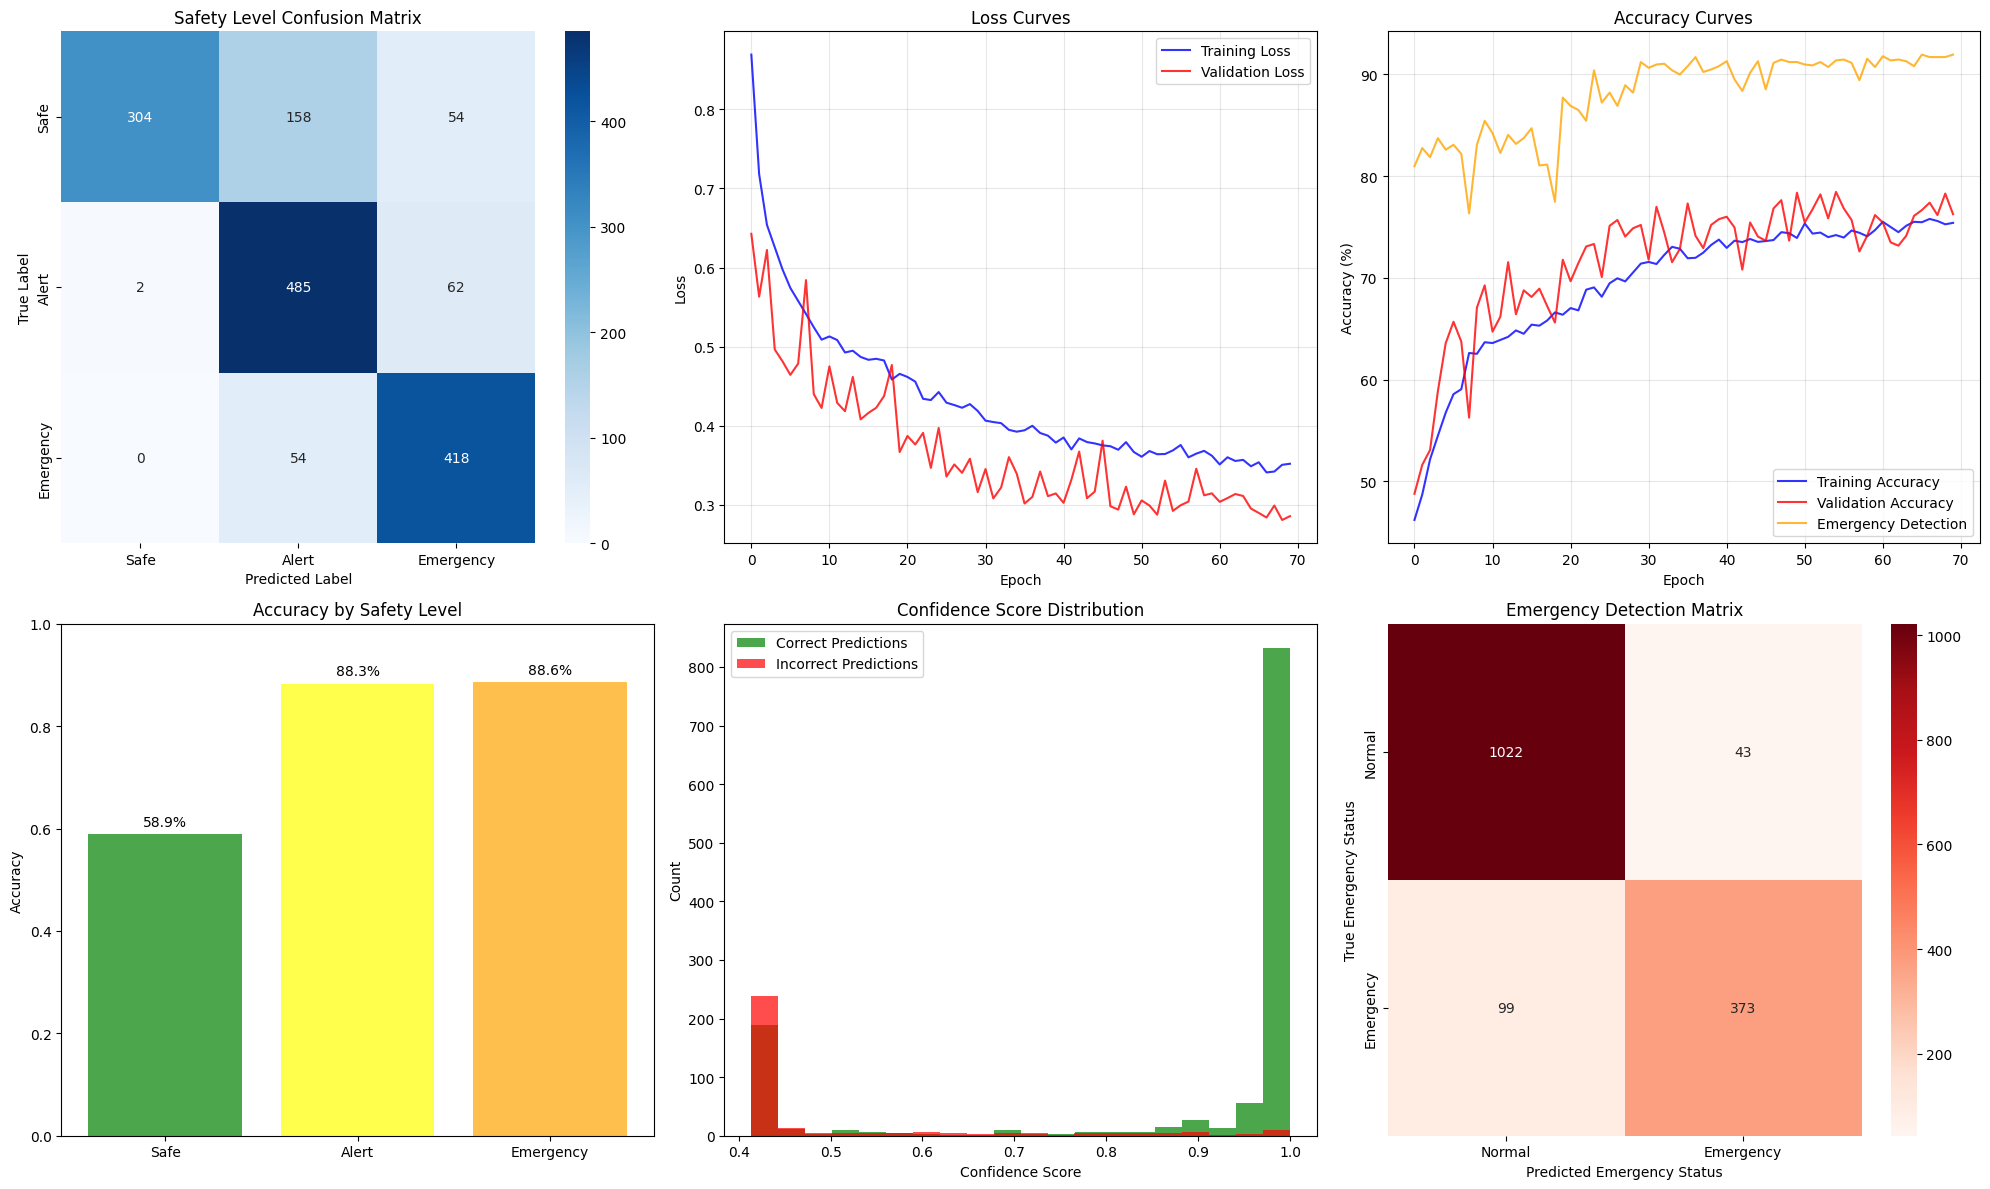


📈 Comprehensive evaluation completed!
🎯 Final Model Performance Summary:
  📊 Overall Accuracy: 78.53%
  🚨 Emergency Detection Accuracy: 90.76%
  📊 Classes detected in model: 3 out of 4 possible
  📊 Class Accuracies:
    Safe: 58.9%
    Alert: 88.3%
    Emergency: 88.6%

🔍 Model Analysis:
  📊 Total test samples: 1537
  📊 Classes distribution in test set:
    Safe: 516 samples (33.6%)
    Alert: 549 samples (35.7%)
    Emergency: 472 samples (30.7%)

✅ Model evaluation visualization saved!


In [13]:
# Load and evaluate the best model
checkpoint = torch.load(config.model_save_path)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"🏆 Best model loaded with {checkpoint['best_accuracy']:.2f}% accuracy")

# Helper function to handle tensor squeezing safely
def safe_squeeze(tensor):
    """Safely squeeze tensor without creating 0-dim tensors"""
    if tensor.dim() == 0:
        return tensor.unsqueeze(0)
    elif tensor.dim() == 1:
        return tensor
    else:
        return tensor.squeeze()

# Comprehensive evaluation with fixes
def comprehensive_evaluation():
    model.eval()
    all_predictions = []
    all_targets = []
    all_emergency_preds = []
    all_emergency_targets = []
    all_confidences = []

    with torch.no_grad():
        for data, safety_target, emergency_target in test_loader:
            data = data.to(device)
            safety_target = safety_target.to(device)
            emergency_target = emergency_target.to(device)

            safety_pred, emergency_pred, confidence_pred = model(data)

            # Safety predictions
            _, predicted = safety_pred.max(1)
            all_predictions.extend(predicted.cpu().numpy())
            all_targets.extend(safety_target.cpu().numpy())

            # Emergency predictions - FIX: safe handling of tensor dimensions
            emergency_predicted = (safe_squeeze(emergency_pred) > 0.5).float()

            # Convert to numpy and extend lists safely
            emergency_pred_np = emergency_predicted.cpu().numpy()
            emergency_target_np = emergency_target.cpu().numpy()

            # Handle both scalar and array cases
            if emergency_pred_np.ndim == 0:
                all_emergency_preds.append(float(emergency_pred_np))
            else:
                all_emergency_preds.extend(emergency_pred_np.tolist())

            if emergency_target_np.ndim == 0:
                all_emergency_targets.append(float(emergency_target_np))
            else:
                all_emergency_targets.extend(emergency_target_np.tolist())

            # Confidence scores
            confidence_np = safe_squeeze(confidence_pred).cpu().numpy()
            if confidence_np.ndim == 0:
                all_confidences.append(float(confidence_np))
            else:
                all_confidences.extend(confidence_np.tolist())

    return all_predictions, all_targets, all_emergency_preds, all_emergency_targets, all_confidences

predictions, targets, emergency_preds, emergency_targets, confidences = comprehensive_evaluation()

# FIX: Determine actual unique labels in predictions and targets
unique_labels = sorted(set(np.unique(targets).tolist() + np.unique(predictions).tolist()))
print(f"📊 Unique labels detected in data: {unique_labels}")

# Create corresponding target names for actual classes
safety_levels = ['Safe', 'Alert', 'Emergency', 'Critical']
actual_target_names = [safety_levels[i] for i in unique_labels if i < len(safety_levels)]

print(f"📊 Classes present: {actual_target_names}")

# Classification report with corrected parameters
print("\n📊 Comprehensive Classification Report:")
print("=" * 60)
print(classification_report(
    targets,
    predictions,
    labels=unique_labels,  # Specify actual labels
    target_names=actual_target_names,  # Match number of labels
    digits=4,
    zero_division=0
))

# Emergency detection performance
emergency_accuracy = np.mean(np.array(emergency_preds) == np.array(emergency_targets))
print(f"\n🚨 Emergency Detection Performance:")
print(f"  Binary Accuracy: {emergency_accuracy:.2%}")

# Calculate precision and recall safely
emergency_preds_arr = np.array(emergency_preds)
emergency_targets_arr = np.array(emergency_targets)

true_positives = np.sum((emergency_preds_arr == 1) & (emergency_targets_arr == 1))
predicted_positives = np.sum(emergency_preds_arr == 1)
actual_positives = np.sum(emergency_targets_arr == 1)

precision = true_positives / max(1, predicted_positives)
recall = true_positives / max(1, actual_positives)
f1_score = 2 * precision * recall / max(0.001, precision + recall)

print(f"  Precision: {precision:.2%}")
print(f"  Recall: {recall:.2%}")
print(f"  F1-Score: {f1_score:.2%}")

# Confidence analysis
print(f"\n🎯 Confidence Analysis:")
print(f"  Average confidence: {np.mean(confidences):.2%}")

correct_confidences = [conf for i, conf in enumerate(confidences) if predictions[i] == targets[i]]
incorrect_confidences = [conf for i, conf in enumerate(confidences) if predictions[i] != targets[i]]

if correct_confidences:
    print(f"  Confidence for correct predictions: {np.mean(correct_confidences):.2%}")
if incorrect_confidences:
    print(f"  Confidence for incorrect predictions: {np.mean(incorrect_confidences):.2%}")

# Create comprehensive visualizations
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# 1. Confusion Matrix with actual labels
cm = confusion_matrix(targets, predictions, labels=unique_labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=actual_target_names, yticklabels=actual_target_names, ax=axes[0,0])
axes[0,0].set_title('Safety Level Confusion Matrix')
axes[0,0].set_ylabel('True Label')
axes[0,0].set_xlabel('Predicted Label')

# 2. Training Curves
axes[0,1].plot(train_losses, label='Training Loss', alpha=0.8, color='blue')
axes[0,1].plot(val_losses, label='Validation Loss', alpha=0.8, color='red')
axes[0,1].set_title('Loss Curves')
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('Loss')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# 3. Accuracy Curves
axes[0,2].plot(train_accuracies, label='Training Accuracy', alpha=0.8, color='blue')
axes[0,2].plot(val_accuracies, label='Validation Accuracy', alpha=0.8, color='red')
axes[0,2].plot(emergency_accuracies, label='Emergency Detection', alpha=0.8, color='orange')
axes[0,2].set_title('Accuracy Curves')
axes[0,2].set_xlabel('Epoch')
axes[0,2].set_ylabel('Accuracy (%)')
axes[0,2].legend()
axes[0,2].grid(True, alpha=0.3)

# 4. Class-wise Accuracy for actual classes
class_accuracies = []
for i in unique_labels:
    class_mask = np.array(targets) == i
    if np.sum(class_mask) > 0:
        class_acc = np.mean(np.array(predictions)[class_mask] == i)
        class_accuracies.append(class_acc)
    else:
        class_accuracies.append(0)

colors = ['green', 'yellow', 'orange', 'red'][:len(actual_target_names)]
bars = axes[1,0].bar(actual_target_names, class_accuracies, color=colors, alpha=0.7)
axes[1,0].set_title('Accuracy by Safety Level')
axes[1,0].set_ylabel('Accuracy')
axes[1,0].set_ylim(0, 1)
for bar, acc in zip(bars, class_accuracies):
    axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                   f'{acc:.1%}', ha='center', va='bottom')

# 5. Confidence Distribution
if correct_confidences:
    axes[1,1].hist(correct_confidences, bins=20, alpha=0.7, label='Correct Predictions', color='green')
if incorrect_confidences:
    axes[1,1].hist(incorrect_confidences, bins=20, alpha=0.7, label='Incorrect Predictions', color='red')
axes[1,1].set_title('Confidence Score Distribution')
axes[1,1].set_xlabel('Confidence Score')
axes[1,1].set_ylabel('Count')
axes[1,1].legend()

# 6. Emergency Detection Matrix
emergency_levels = ['Normal', 'Emergency']
emergency_cm = confusion_matrix(emergency_targets, emergency_preds)
sns.heatmap(emergency_cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=emergency_levels, yticklabels=emergency_levels, ax=axes[1,2])
axes[1,2].set_title('Emergency Detection Matrix')
axes[1,2].set_ylabel('True Emergency Status')
axes[1,2].set_xlabel('Predicted Emergency Status')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/WomenSafetyAI/comprehensive_evaluation.png',
            dpi=300, bbox_inches='tight')
plt.show()

print("\n📈 Comprehensive evaluation completed!")
print(f"🎯 Final Model Performance Summary:")
print(f"  📊 Overall Accuracy: {np.mean(np.array(predictions) == np.array(targets)):.2%}")
print(f"  🚨 Emergency Detection Accuracy: {emergency_accuracy:.2%}")
print(f"  📊 Classes detected in model: {len(unique_labels)} out of 4 possible")
print(f"  📊 Class Accuracies:")
for i, (level, acc) in enumerate(zip(actual_target_names, class_accuracies)):
    print(f"    {level}: {acc:.1%}")

# Additional model analysis
print(f"\n🔍 Model Analysis:")
print(f"  📊 Total test samples: {len(targets)}")
print(f"  📊 Classes distribution in test set:")
for label in unique_labels:
    count = np.sum(np.array(targets) == label)
    percentage = count / len(targets) * 100
    print(f"    {actual_target_names[unique_labels.index(label)]}: {count} samples ({percentage:.1f}%)")

print("\n✅ Model evaluation visualization saved!")
